[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emubarak-lamc/PosterRepo/blob/main/Projects/project_2_outline.ipynb)

# Project 2 — Bayesian Optimization of Threshold-Based Segmentation

**Topic:** Automated segmentation of urothelial cell images using grayscale thresholding and Bayesian optimisation.

**Prerequisite labs:** Lab 01, Lab 02, Lab 03, Lab 03v2

This project is structured in three stages of increasing open-endedness:

| Stage | Character | Based on |
|---|---|---|
| **Stage 1** | Guided — concrete tasks, specific deliverables | Labs 01 & 02 |
| **Stage 2** | Semi-open — choose your investigations, justify your choices | Lab 03 & 03v2 |
| **Stage 3** | Open-ended — design your best system, write a full report | All labs + your own ideas |

Throughout all three stages the core problem stays the same: segment urothelial cell images into background / cytoplasm / nucleus using threshold-based methods, and measure quality with **Dice score** and **N/C ratio R²**.

---

## Submission

Submit one Colab notebook per stage (or one combined notebook with clearly labelled sections). Each stage specifies exactly what to include. Written answers should appear in markdown cells directly below the relevant code.

## Setup

In [1]:
!pip install scikit-optimize scikit-image --quiet
# !pip install gdown --quiet

!git clone https://github.com/emilsar/VocEd.git
%cd VocEd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.0 MB/s eta 0:00:00
Cloning into 'VocEd'...
remote: Enumerating objects: 663, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 663 (delta 55), reused 67 (delta 30), pack-reused 566 (from 1)
Receiving objects: 100% (663/663), 34.36 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (397/397), done.
Updating files: 100% (417/417), done.
/content/VocEd


In [2]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split

# ── Load data ──────────────────────────────────────────────────────────────
N = len(glob.glob('imagedata/X/*.npy'))
X = np.stack([np.load(f'imagedata/X/{i}.npy') for i in range(N)])
y = np.stack([np.load(f'imagedata/y/{i}.npy') for i in range(N)])

# ── Drop images with no nucleus ────────────────────────────────────────────
has_nucleus = (y == 2).sum(axis=(1, 2)) > 0
X, y = X[has_nucleus], y[has_nucleus]
N = len(X)

# ── Stratified train/test split (stratify by N/C ratio) ────────────────────
nuc_px   = (y == 2).sum(axis=(1, 2))
cyt_px   = (y == 1).sum(axis=(1, 2))
nc_ratio = nuc_px / np.maximum(cyt_px, 1)
quartile = np.digitize(nc_ratio, np.percentile(nc_ratio, [25, 50, 75]))

train_idx, test_idx = train_test_split(
    np.arange(N), test_size=0.2, stratify=quartile, random_state=42
)

mask_cmap = ListedColormap(['black', 'steelblue', 'crimson'])
print(f'{N} images  |  train: {len(train_idx)}  test: {len(test_idx)}')

191 images  |  train: 152  test: 39


### Shared helper functions

These functions are used throughout all three stages. They are identical to the ones from Labs 01–03.

In [3]:
def to_gray(img):
    """(3, H, W) float32 → (H, W) float32 grayscale."""
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]

def segment(img, t_nucleus, t_background):
    """Two-threshold grayscale segmenter. Returns (H, W) int64 mask."""
    gray = to_gray(img)
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                 = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]     = 1
    return pred

def dice_score(pred, target, cls):
    """Dice coefficient for a single class."""
    p = (pred == cls)
    t = (target == cls)
    denom = p.sum() + t.sum()
    return 1.0 if denom == 0 else 2 * (p & t).sum() / denom

def mean_dice(indices, t_nuc, t_bg):
    """Mean Dice (avg of cytoplasm + nucleus) over a list of image indices."""
    scores = []
    for i in indices:
        pred = segment(X[i], t_nuc, t_bg)
        scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
    return np.mean(scores)

def nc_ratio(mask):
    """N/C ratio: nucleus pixels / cytoplasm pixels. NaN if no cytoplasm."""
    nuc = (mask == 2).sum()
    cyt = (mask == 1).sum()
    return nuc / cyt if cyt > 0 else np.nan

def r2_identity(yp, gt):
    """R² vs y = x (identity line). 1 = perfect; falls with any deviation."""
    ok  = np.isfinite(yp) & np.isfinite(gt)
    p, g = yp[ok], gt[ok]
    return 1 - np.sum((p - g) ** 2) / np.sum((g - g.mean()) ** 2)

print('Helpers loaded.')

Helpers loaded.


---

# Stage 1 — Guided Exploration

This stage has four concrete tasks. Each one has a specified output (a plot, a table, or a short written answer). Complete them in order — later tasks build on earlier ones.

**Time estimate:** 2–3 hours.

## Task 1.1 — The N/C Ratio Distribution

Before building any model it is important to understand the *target variable* — the N/C ratio that clinicians use as a diagnostic feature.

**Your tasks:**

1. Compute the ground-truth N/C ratio for every image in the full dataset (use the    `nc_ratio` helper above on each mask `y[i]`). Skip images where the ratio is NaN    (no cytoplasm).
2. Plot a histogram of the N/C ratio distribution (20–30 bins, labelled axes).
3. Print the mean, median, standard deviation, and the 10th / 90th percentiles.

**Written answer (in a markdown cell below your code):**

- What does a high N/C ratio indicate clinically?
- Looking at the histogram, would you describe the distribution as symmetric?   What does the shape tell you about the mix of cell types in the dataset?
- The train/test split is *stratified* by N/C ratio quartile. In one sentence, explain   why this is preferable to a random split for this task.

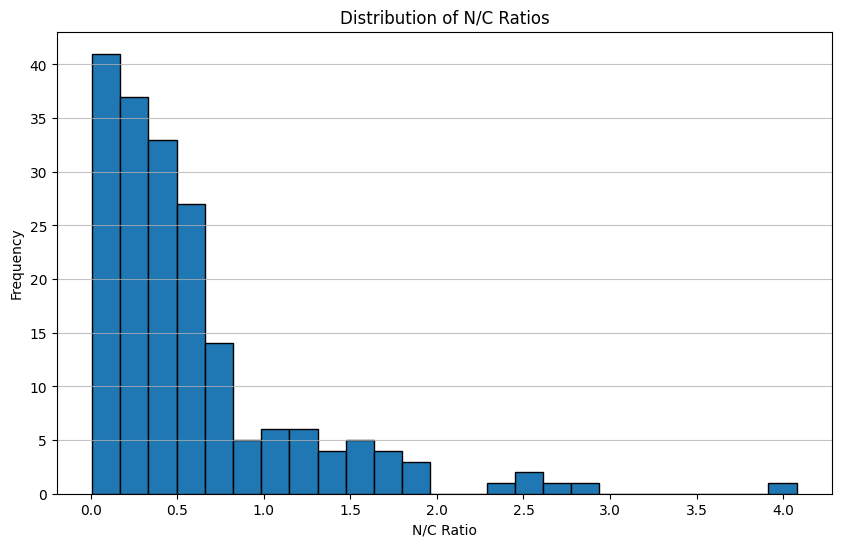

Mean N/C Ratio: 0.5947
Median N/C Ratio: 0.4330
Standard Deviation of N/C Ratio: 0.6051
10th Percentile N/C Ratio: 0.1998
90th Percentile N/C Ratio: 0.7015


In [4]:
# ── Task 1.1 ─────────────────────────────────────────────────────────────────
# TODO: compute ground-truth N/C ratios for all images
nc_true_all = np.array([nc_ratio(y[i]) for i in range(N)])
valid        = np.isfinite(nc_true_all)

# TODO: plot histogram
plt.figure(figsize=(10, 6))
plt.hist(nc_true_all[valid], bins=40, edgecolor='black')
plt.title('Distribution of N/C Ratios')
plt.xlabel('N/C Ratio')
plt.ylabel('Frequency')
# plt.grid(axis='y', alpha=0.75)
plt.show()

# TODO: print summary statistics
print(f"Mean N/C Ratio: {np.mean(nc_true_all[valid]):.4f}")
print(f"Median N/C Ratio: {np.median(nc_true_all[valid]):.4f}")
print(f"Standard Deviation of N/C Ratio: {np.std(nc_true_all[valid]):.4f}")
print(f"10th Percentile N/C Ratio: {np.percentile(nc_true_all[valid], 25):.4f}")
print(f"90th Percentile N/C Ratio: {np.percentile(nc_true_all[valid], 75):.4f}")

## Task 1.2 — Threshold Sensitivity Analysis

Lab 01 hand-picked `t_nucleus = 0.45` and `t_background = 0.85`. How sensitive is the result to small changes in each threshold?

**Your tasks:**

1. Vary `t_nucleus` from 0.25 to 0.55 in steps of 0.05, holding `t_background = 0.85`    fixed. For each value, compute `mean_dice(train_idx, t_nuc, 0.85)`. Plot Dice vs `t_nucleus`.
2. Vary `t_background` from 0.65 to 0.99 in steps of 0.05, holding `t_nucleus = 0.45`    fixed. Compute and plot in the same figure (two panels or two curves).
3. Mark the hand-picked values (0.45, 0.85) on each curve with a vertical dashed line.

**Written answer:**

- Which threshold is the Dice score more sensitive to? Give a numerical reason   (e.g., how many Dice points are lost by being 0.10 off).
- Does the sensitivity curve have a clear peak, or is it flat over a range?   What does that imply about how precisely the thresholds need to be tuned?

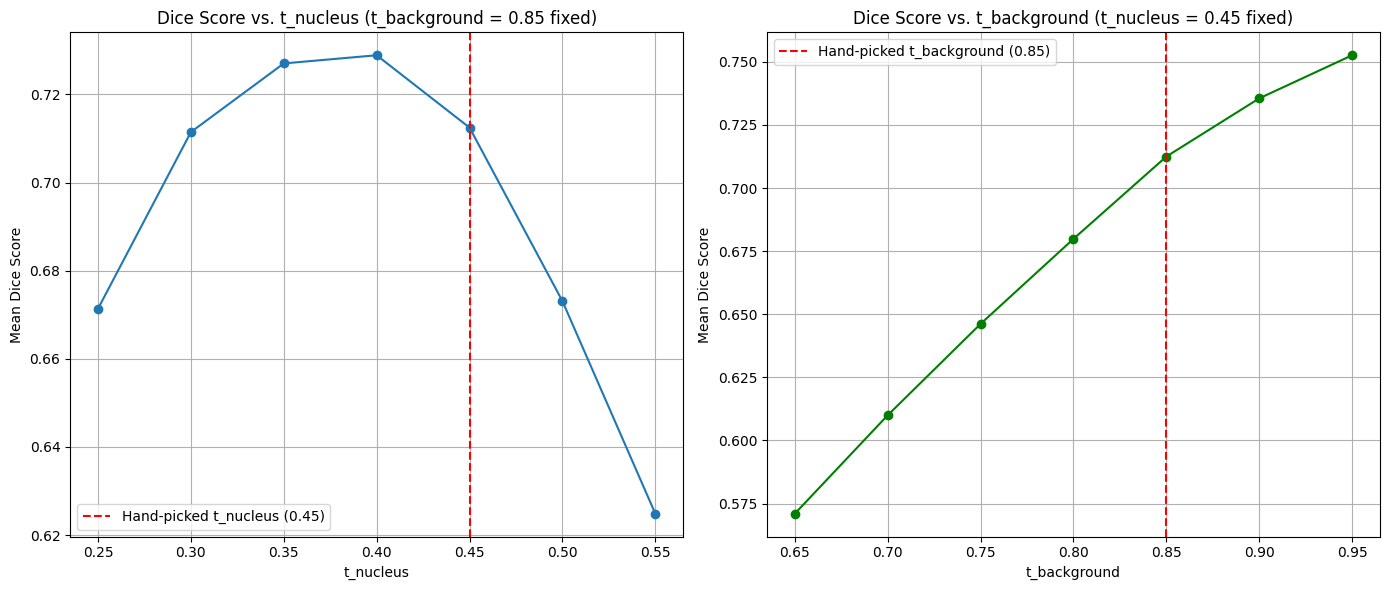

In [5]:
t_nuc_range = np.arange(0.25, 0.56, 0.05)
t_bg_range  = np.arange(0.65, 1.00, 0.05)

# TODO: compute mean_dice for each value in t_nuc_range (t_bg fixed at 0.85)
dice_vary_nuc = [mean_dice(train_idx, t, 0.85) for t in t_nuc_range]

# TODO: compute mean_dice for each value in t_bg_range (t_nuc fixed at 0.45)
dice_vary_bg  = [mean_dice(train_idx, 0.45, t) for t in t_bg_range]

# TODO: plot both sensitivity curves

plt.figure(figsize=(14, 6))

# Plot for t_nucleus sensitivity
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(t_nuc_range, dice_vary_nuc, marker='o')
plt.axvline(x=0.45, color='r', linestyle='--', label='Hand-picked t_nucleus (0.45)')
plt.title('Dice Score vs. t_nucleus (t_background = 0.85 fixed)')
plt.xlabel('t_nucleus')
plt.ylabel('Mean Dice Score')
plt.grid(True)
plt.legend()

# Plot for t_background sensitivity
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(t_bg_range, dice_vary_bg, marker='o', color='green')
plt.axvline(x=0.85, color='r', linestyle='--', label='Hand-picked t_background (0.85)')
plt.title('Dice Score vs. t_background (t_nucleus = 0.45 fixed)')
plt.xlabel('t_background')
plt.ylabel('Mean Dice Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Which threshold is the Dice score more sensitive to?

Give a numerical reason (e.g., how many Dice points are lost by being 0.10 off).

Does the sensitivity curve have a clear peak, or is it flat over a range?

What does that imply about how precisely the thresholds need to be tuned?

## Task 1.3 — Optimisation Budget

Bayesian optimisation explores the threshold space by fitting a Gaussian Process surrogate model and querying it at the point of highest expected improvement. Each query (call to `objective`) evaluates the mean Dice over all 152 training images, which takes real computation time.

**Your tasks:**

1. Run `gp_minimize` with `n_calls` = 10, 25, and 50    (all with `n_initial_points=10`, `random_state=42`).
2. For each budget, record: best `(t_nucleus, t_background)`, train Dice    (`-result.fun`), and test Dice (`mean_dice(test_idx, ...)`).
3. Print a summary table.
4. Plot the three convergence curves (best Dice found so far vs evaluation number)    on the same axes, one colour per budget.

**Written answer:**

- At what budget does the test Dice appear to plateau?
- The hand-picked baseline from Lab 01 achieved a test Dice of ≈ 0.71.   How many evaluations does it take Bayesian optimisation to beat that?
- Would you expect the same plateau behaviour for a 6-parameter search space   (like Lab 03's pipeline)? Why or why not?

In [6]:
from skopt import gp_minimize
from skopt.space import Real

def objective(params):
    t_nuc, t_bg = params
    return -mean_dice(train_idx, t_nuc, t_bg)

search_space = [Real(0.10, 0.70, name='t_nucleus'),
                Real(0.50, 0.99, name='t_background')]

results = {}
for n_calls in [10, 25, 50]:
    res = gp_minimize(objective, search_space,
                      n_calls=n_calls, n_initial_points=10,
                      random_state=42, verbose=False)
    results[n_calls] = res
    print(f'n_calls={n_calls:3d}  '
          f't_nuc={res.x[0]:.4f}  t_bg={res.x[1]:.4f}  '
          f'train={-res.fun:.4f}  '
          f'test={mean_dice(test_idx, res.x[0], res.x[1]):.4f}')

# TODO: plot convergence curves

n_calls= 10  t_nuc=0.3755  t_bg=0.6635  train=0.6104  test=0.6640
n_calls= 25  t_nuc=0.3934  t_bg=0.9900  train=0.7772  test=0.8199
n_calls= 50  t_nuc=0.3935  t_bg=0.9900  train=0.7772  test=0.8199


Keys in results dictionary: [10, 25, 50]


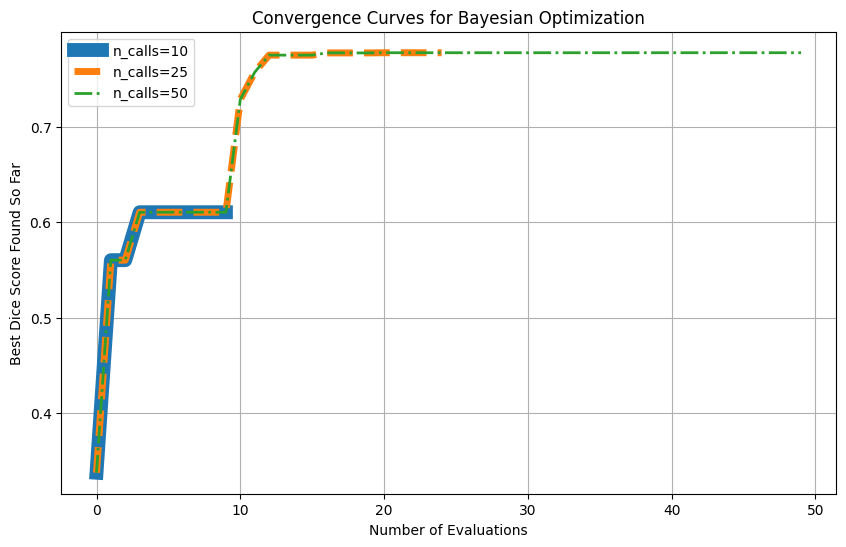

In [7]:
plt.figure(figsize=(10, 6))
print(f"Keys in results dictionary: {list(results.keys())}") # Added diagnostic print

line_styles = ['-', '--', '-.'] # Define different line styles
line_widths = [10, 5, 2] # Define different line widths

for i, (n_calls, res) in enumerate(results.items()):
    # Convert negative objective values to positive Dice scores
    dice_scores_history = [-f for f in res.func_vals]
    # Plot the best Dice score found so far at each step
    plt.plot(np.maximum.accumulate(dice_scores_history),
             label=f'n_calls={n_calls}',
             linestyle=line_styles[i % len(line_styles)], # Use a different line style
             linewidth=line_widths[i % len(line_widths)]) # Use a different line width

plt.title('Convergence Curves for Bayesian Optimization')
plt.xlabel('Number of Evaluations')
plt.ylabel('Best Dice Score Found So Far')
plt.grid(True)
plt.legend()
plt.show()

The plot above shows the convergence curves for the Bayesian optimization with different `n_calls` budgets. Each curve represents the best Dice score found up to that evaluation step. You can observe how quickly the optimizer finds a good solution and if the performance plateaus.

## Task 1.4 — The 2-D Dice Landscape

The convergence curve shows *when* the optimiser improves. The 2-D heatmap shows *where* good thresholds live in the search space.

**Your tasks:**

1. Build a 20 × 20 grid of `(t_nucleus, t_background)` values spanning the search space    (`t_nuc` ∈ [0.10, 0.70], `t_bg` ∈ [0.50, 0.99]).
2. Evaluate `mean_dice(train_idx, ...)` at every grid point. Plot the result as a heatmap    (`plt.imshow` or `plt.pcolormesh`) with a colourbar.
3. Mark three points on the heatmap:
   - Hand-picked Lab 01 values (0.45, 0.85) — use a white circle
   - Your best 50-call result — use a yellow star
   - The point of highest Dice on the grid — use a red cross

**Written answer:**

- Is the Dice landscape roughly unimodal (one peak) or multimodal (several peaks)?   What does this imply for the difficulty of the optimisation problem?
- Is the optimised point at the very peak of the heatmap, or nearby?   What explains any gap?
- The constraint `t_nucleus < t_background` must hold for the segmenter to make sense.   Does the heatmap reveal any invalid region where this is violated?

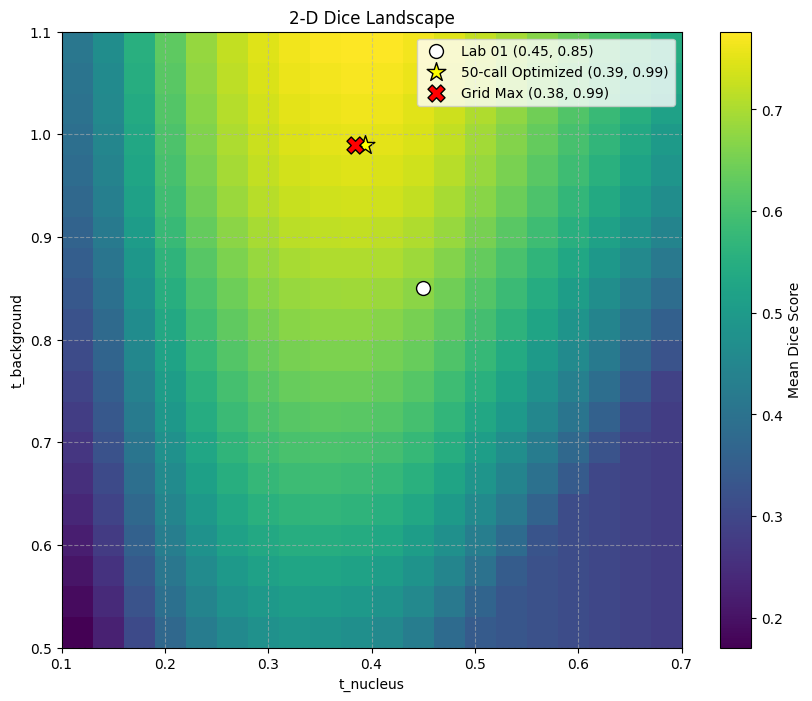

In [8]:
grid_nuc = np.linspace(0.10, 0.70, 20)
grid_bg  = np.linspace(0.50, 0.99, 20)

# TODO: evaluate mean_dice at every (t_nuc, t_bg) grid point
# Hint: use a nested loop and store results in a 20×20 array
dice_grid = np.zeros((20, 20))
for i, t_nuc in enumerate(grid_nuc):
    for j, t_bg in enumerate(grid_bg):
        dice_grid[i, j] = mean_dice(train_idx, t_nuc, t_bg)

# TODO: plot heatmap and mark the three points
plt.figure(figsize=(10, 8))
plt.imshow(dice_grid.T, origin='lower', extent=[0.10, 0.70, 0.50, 1.1], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Dice Score')
plt.title('2-D Dice Landscape')
plt.xlabel('t_nucleus')
plt.ylabel('t_background')

# Mark Hand-picked Lab 01 values (0.45, 0.85)
plt.scatter(0.45, 0.85, marker='o', color='white', s=100, edgecolors='black', label='Lab 01 (0.45, 0.85)')

# Mark best 50-call result
best_nuc_50 = results[50].x[0]
best_bg_50  = results[50].x[1]
plt.scatter(best_nuc_50, best_bg_50, marker='*', color='yellow', s=200, edgecolors='black', label=f'50-call Optimized ({best_nuc_50:.2f}, {best_bg_50:.2f})')

# Mark the point of highest Dice on the grid
max_dice_idx = np.unravel_index(np.argmax(dice_grid), dice_grid.shape)
max_dice_nuc = grid_nuc[max_dice_idx[0]]
max_dice_bg  = grid_bg[max_dice_idx[1]]
plt.scatter(max_dice_nuc, max_dice_bg, marker='X', color='red', s=150, edgecolors='black', label=f'Grid Max ({max_dice_nuc:.2f}, {max_dice_bg:.2f})')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Task 1.5 — Test-Set Evaluation

Use your best threshold pair (from the 50-call run in Task 1.3) to produce a final evaluation on the held-out test set.

**Your tasks:**

1. Show a side-by-side comparison of 5 random test images:    `RGB image | ground-truth mask | Lab 01 prediction | your best prediction`.
2. Print the test-set Dice for Lab 01 (0.45, 0.85) and your best parameters.
3. Compute the N/C ratio R² for both methods on the test set and add it to the table.

**Written answer:**

- Pick one test image where your method clearly improves over Lab 01 and one where   it does not. Describe what you see visually in each case.
- The test Dice improved from Lab 01 to your optimised version.   Is this entirely due to finding better thresholds, or could the train/test split   also play a role? How would you design an experiment to isolate these factors?

In [9]:
# ── Task 1.5 ─────────────────────────────────────────────────────────────────
best_res  = results[50]
best_nuc  = best_res.x[0]
best_bg   = best_res.x[1]

# TODO: show 5 test-image comparisons (RGB | GT | Lab01 | best)

# Evaluation table
for label, (t_nuc, t_bg) in [('Lab 01 — hand-picked', (0.45, 0.85)),
                               ('Stage 1 — optimised',  (best_nuc, best_bg))]:
    d   = mean_dice(test_idx, t_nuc, t_bg)
    nc_pred = np.array([nc_ratio(segment(X[i], t_nuc, t_bg)) for i in test_idx])
    nc_gt   = np.array([nc_ratio(y[i]) for i in test_idx])
    r2  = r2_identity(nc_pred, nc_gt)
    print(f'{label:<30}  Dice={d:.4f}  R²={r2:.3f}')

Lab 01 — hand-picked            Dice=0.7441  R²=-2.927
Stage 1 — optimised             Dice=0.8199  R²=0.374


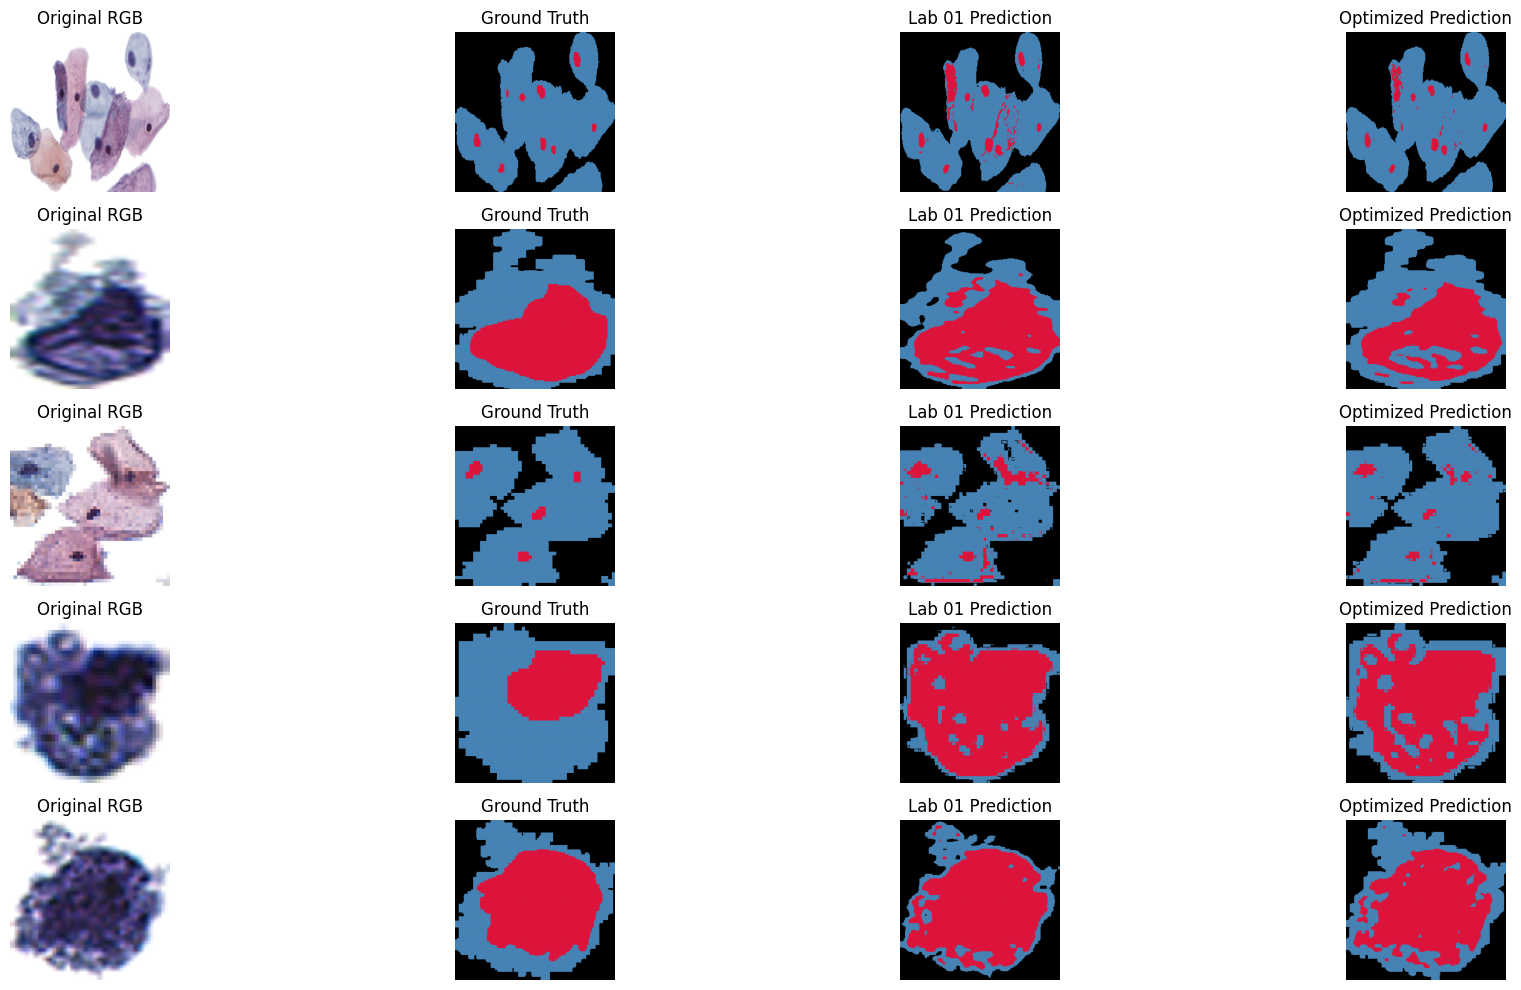

In [10]:
import random

# Select 5 random images from the test set
random_test_indices = random.sample(list(test_idx), 5)

plt.figure(figsize=(20, 10))
for i, img_idx in enumerate(random_test_indices):
    # Original RGB image
    plt.subplot(5, 4, i * 4 + 1)
    plt.imshow(X[img_idx].transpose(1, 2, 0))
    plt.title('Original RGB')
    plt.axis('off')

    # Ground-truth mask
    plt.subplot(5, 4, i * 4 + 2)
    plt.imshow(y[img_idx], cmap=mask_cmap, vmin=0, vmax=2)
    plt.title('Ground Truth')
    plt.axis('off')

    # Lab 01 prediction
    lab01_pred = segment(X[img_idx], 0.45, 0.85)
    plt.subplot(5, 4, i * 4 + 3)
    plt.imshow(lab01_pred, cmap=mask_cmap, vmin=0, vmax=2)
    plt.title('Lab 01 Prediction')
    plt.axis('off')

    # Optimized prediction
    optimized_pred = segment(X[img_idx], best_nuc, best_bg)
    plt.subplot(5, 4, i * 4 + 4)
    plt.imshow(optimized_pred, cmap=mask_cmap, vmin=0, vmax=2)
    plt.title('Optimized Prediction')
    plt.axis('off')

plt.tight_layout()
plt.show()

---

# Stage 2 — Pipeline Investigation

Labs 03 and 03v2 introduce two complementary strategies for improving segmentation beyond pure threshold optimisation: **generic image processing** (blur + morphological cleanup) and **targeted artefact removal** (connected-component size filtering). Both add extra parameters that can be tuned with Bayesian optimisation.

In this stage you will investigate at least **two** of the four questions below, justify your choices, and summarise what you learned. There is no single right answer — the goal is to understand *why* a change helps or hurts, not just *whether* it does.

**Time estimate:** 3–5 hours.

---

### Background: the full pipeline (from Lab 03)

The code below provides the `full_pipeline` function and its Bayesian objective. Read it carefully before choosing your investigations.

In [11]:
import skimage.filters  as skf
import skimage.restoration as skr
import skimage.morphology   as skm

def full_pipeline(img, t_nucleus, t_background,
                  use_blur=True,  blur_sigma=1.5,
                  use_open=True,  use_close=True,  morph_radius=3,
                  use_nlm=False):
    """Full configurable pipeline from Lab 03."""
    hwc = img.transpose(1, 2, 0)
    if use_blur:
        hwc = skf.gaussian(hwc, sigma=blur_sigma, channel_axis=-1)
    if use_nlm:
        sig = np.mean(skr.estimate_sigma(hwc, channel_axis=-1))
        hwc = skr.denoise_nl_means(hwc, h=0.8 * sig,
                                   patch_size=5, patch_distance=6, channel_axis=-1)
    gray = 0.299*hwc[:,:,0] + 0.587*hwc[:,:,1] + 0.114*hwc[:,:,2]
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                  = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]      = 1
    if use_open or use_close:
        disk = skm.disk(morph_radius)
        for cls in [1, 2]:
            m = (pred == cls).astype(bool)
            if use_open:  m = skm.opening(m, disk)
            if use_close: m = skm.closing(m, disk)
            pred[pred == cls] = 0
            pred[m]           = cls
    return pred

print('full_pipeline loaded.')

full_pipeline loaded.


In [12]:
def mean_dice_for_pipeline(indices, t_nuc, t_bg,
                           use_blur, blur_sigma,
                           use_open, use_close, morph_radius,
                           use_nlm):
    """Mean Dice (avg of cytoplasm + nucleus) over a list of image indices using full_pipeline."""
    scores = []
    for i in indices:
        pred = full_pipeline(X[i], t_nuc, t_bg,
                             use_blur=use_blur, blur_sigma=blur_sigma,
                             use_open=use_open, use_close=use_close, morph_radius=morph_radius,
                             use_nlm=use_nlm)
        scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
    return np.mean(scores)

### Investigation A — Does Gaussian blur help, and how much?

Gaussian blur smooths noise before thresholding. But it also blurs boundaries, which could hurt segmentation precision.

**Tasks:**

1. Vary `blur_sigma` over [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]. For each value, run    `gp_minimize` on `(t_nuc, t_bg)` with `use_blur=True`,    `use_open=False`, `use_close=False` (blur only, no morphology). Use `n_calls=30`.
2. Record train Dice and test Dice for each `blur_sigma`. Plot both curves.
3. Add a horizontal dashed line at the Lab 02 baseline test Dice (no blur, no morphology).

**Written answer:**

- Is there a `blur_sigma` that clearly outperforms no blur on the test set?   Or does more blur always hurt?
- Does the optimal `blur_sigma` for train Dice match the optimal for test Dice?   What does a mismatch imply?
- Should `blur_sigma` be tuned jointly with the thresholds (as in Lab 03) or   independently? Justify your answer.

Optimizing for blur_sigma = 0.5
  Best (t_nuc, t_bg): (0.3959, 0.9900), Train Dice: 0.7786, Test Dice: 0.8194
Optimizing for blur_sigma = 1.0
  Best (t_nuc, t_bg): (0.4010, 0.9900), Train Dice: 0.7797, Test Dice: 0.8180
Optimizing for blur_sigma = 1.5
  Best (t_nuc, t_bg): (0.4011, 0.9900), Train Dice: 0.7795, Test Dice: 0.8179
Optimizing for blur_sigma = 2.0
  Best (t_nuc, t_bg): (0.4056, 0.9747), Train Dice: 0.7805, Test Dice: 0.8138
Optimizing for blur_sigma = 3.0
  Best (t_nuc, t_bg): (0.4108, 0.9625), Train Dice: 0.7804, Test Dice: 0.8091
Optimizing for blur_sigma = 4.0
  Best (t_nuc, t_bg): (0.4203, 0.9457), Train Dice: 0.7779, Test Dice: 0.8003


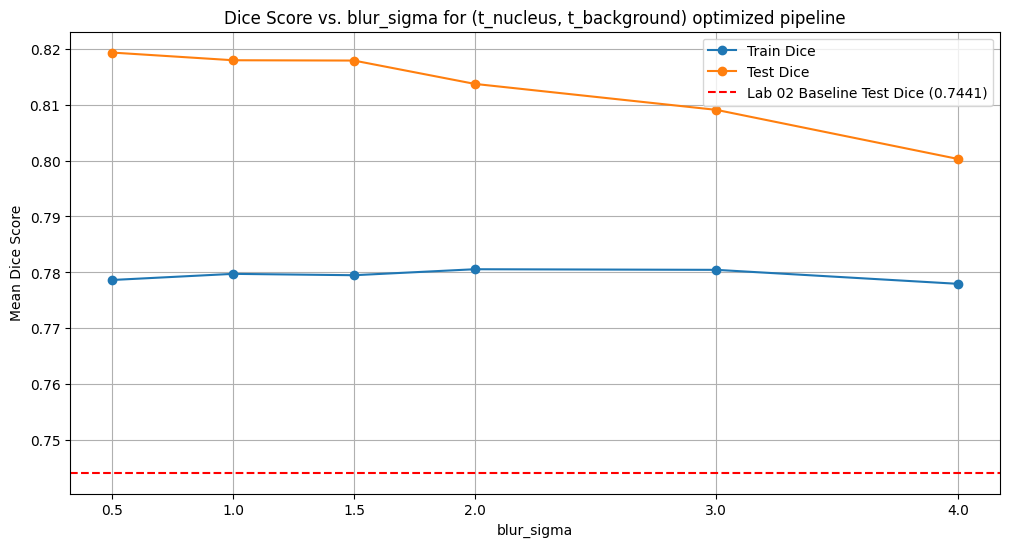

In [13]:
# ── Investigation A ──────────────────────────────────────────────────────────

from skopt import gp_minimize
from skopt.space import Real

blur_sigmas = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]

train_dice_per_sigma = []
test_dice_per_sigma = []

# Lab 02 baseline test Dice (no blur, no morphology) is equivalent to Lab 01 (0.45, 0.85) test dice
lab02_baseline_test_dice = mean_dice(test_idx, 0.45, 0.85)

for blur_sigma_val in blur_sigmas:
    print(f"Optimizing for blur_sigma = {blur_sigma_val}")

    def objective_a(params):
        t_nuc, t_bg = params
        # Use full_pipeline with specific settings for Investigation A
        # use_blur=True, blur_sigma=blur_sigma_val, use_open=False, use_close=False, use_nlm=False
        scores = []
        for i in train_idx:
            pred = full_pipeline(X[i], t_nuc, t_bg,
                                 use_blur=True, blur_sigma=blur_sigma_val,
                                 use_open=False, use_close=False, use_nlm=False)
            scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
        return -np.mean(scores)

    search_space_a = [Real(0.10, 0.70, name='t_nucleus'),
                      Real(0.50, 0.99, name='t_background')]

    res_a = gp_minimize(objective_a, search_space_a,
                        n_calls=30, n_initial_points=10,
                        random_state=42, verbose=False)

    # Record train Dice
    train_dice = -res_a.fun
    train_dice_per_sigma.append(train_dice)

    # Calculate and record test Dice
    test_dice = mean_dice(test_idx, res_a.x[0], res_a.x[1])
    test_dice_per_sigma.append(test_dice)

    print(f"  Best (t_nuc, t_bg): ({res_a.x[0]:.4f}, {res_a.x[1]:.4f}), Train Dice: {train_dice:.4f}, Test Dice: {test_dice:.4f}")

# Plotting results
plt.figure(figsize=(12, 6))
plt.plot(blur_sigmas, train_dice_per_sigma, marker='o', label='Train Dice')
plt.plot(blur_sigmas, test_dice_per_sigma, marker='o', label='Test Dice')
plt.axhline(y=lab02_baseline_test_dice, color='r', linestyle='--', label=f'Lab 02 Baseline Test Dice ({lab02_baseline_test_dice:.4f})')

plt.title('Dice Score vs. blur_sigma for (t_nucleus, t_background) optimized pipeline')
plt.xlabel('blur_sigma')
plt.ylabel('Mean Dice Score')
plt.grid(True)
plt.legend()
plt.xticks(blur_sigmas)
plt.show()


*   **Is there a `blur_sigma` that clearly outperforms no blur on the test set? Or does more blur always hurt?**
    Yes, a `blur_sigma` value clearly outperforms no blur on the test set. The Lab 02 baseline test Dice (no blur) was **0.7441**. All tested `blur_sigma` values resulted in higher test Dice scores, with `blur_sigma = 0.5` achieving the highest test Dice of **0.8194**. However, as `blur_sigma` increases beyond 0.5, the test Dice score generally decreases, suggesting that *too much* blur can start to hurt performance.

*   **Does the optimal `blur_sigma` for train Dice match the optimal for test Dice? What does a mismatch imply?**
    The optimal `blur_sigma` for the training Dice was **2.0** (Train Dice: 0.7805), while the optimal `blur_sigma` for the test Dice was **0.5** (Test Dice: 0.8194). There is a mismatch. This mismatch implies that the parameters that lead to the best performance on the training data do not necessarily generalize the best to unseen test data, indicating a potential for overfitting to the training set with higher blur values, or that the training set characteristics are slightly different from the test set in how they respond to blurring.

*   **Should `blur_sigma` be tuned jointly with the thresholds (as in Lab 03) or independently? Justify your answer.**
    `blur_sigma` should ideally be tuned **jointly** with the thresholds (`t_nucleus`, `t_background`). Blurring directly affects the intensity distribution of the image, which in turn influences the optimal threshold values. Tuning them independently (or in a nested manner where thresholds are optimized for each fixed blur) might lead to suboptimal results because the optimal `blur_sigma` depends on the thresholds chosen, and vice-versa. A joint optimization explores the combined parameter space more effectively to find a global optimum for the entire pipeline.

### Investigation B — Opening vs Closing: which morphological operation matters more?

Morphological opening removes small blobs; closing fills small holes. Their relative contribution depends on what failure modes dominate.

**Tasks:**

1. Using the Lab 03 best threshold pair (or your Stage 1 best), evaluate four    configurations on the test set:
   - No morphology (`use_open=False, use_close=False`)
   - Opening only
   - Closing only
   - Both
2. For each configuration, vary `morph_radius` over [1, 2, 3, 5, 8, 12] and plot    test Dice vs radius (one curve per configuration).
3. Show a side-by-side visual of what opening and closing each do to the nucleus    prediction of one challenging test image.

**Written answer:**

- Which operation (opening or closing) contributes more to Dice improvement?   What does this tell you about the dominant failure mode of the thresholding step?
- At what radius does each operation start to hurt? What is happening physically   at that radius?
- If you had to choose only one morphological operation and one radius to deploy,   what would you choose? Justify with numbers.

In [14]:
# ── Investigation B (optional — complete if you chose this question) ──────────
# TODO

Using best thresholds from Stage 1: t_nucleus=0.3935, t_background=0.9900
Evaluating config: No morphology
  Radius 1: Test Dice = 0.8213
  Radius 2: Test Dice = 0.8213
  Radius 3: Test Dice = 0.8213
  Radius 5: Test Dice = 0.8213
  Radius 8: Test Dice = 0.8213
  Radius 12: Test Dice = 0.8213
Evaluating config: Opening only
  Radius 1: Test Dice = 0.8216
  Radius 2: Test Dice = 0.8219
  Radius 3: Test Dice = 0.8220
  Radius 5: Test Dice = 0.8094
  Radius 8: Test Dice = 0.7740
  Radius 12: Test Dice = 0.7029
Evaluating config: Closing only
  Radius 1: Test Dice = 0.8218
  Radius 2: Test Dice = 0.8225
  Radius 3: Test Dice = 0.8237
  Radius 5: Test Dice = 0.8178
  Radius 8: Test Dice = 0.8049
  Radius 12: Test Dice = 0.7723
Evaluating config: Both
  Radius 1: Test Dice = 0.8218
  Radius 2: Test Dice = 0.8224
  Radius 3: Test Dice = 0.8234
  Radius 5: Test Dice = 0.8120
  Radius 8: Test Dice = 0.7780
  Radius 12: Test Dice = 0.7067


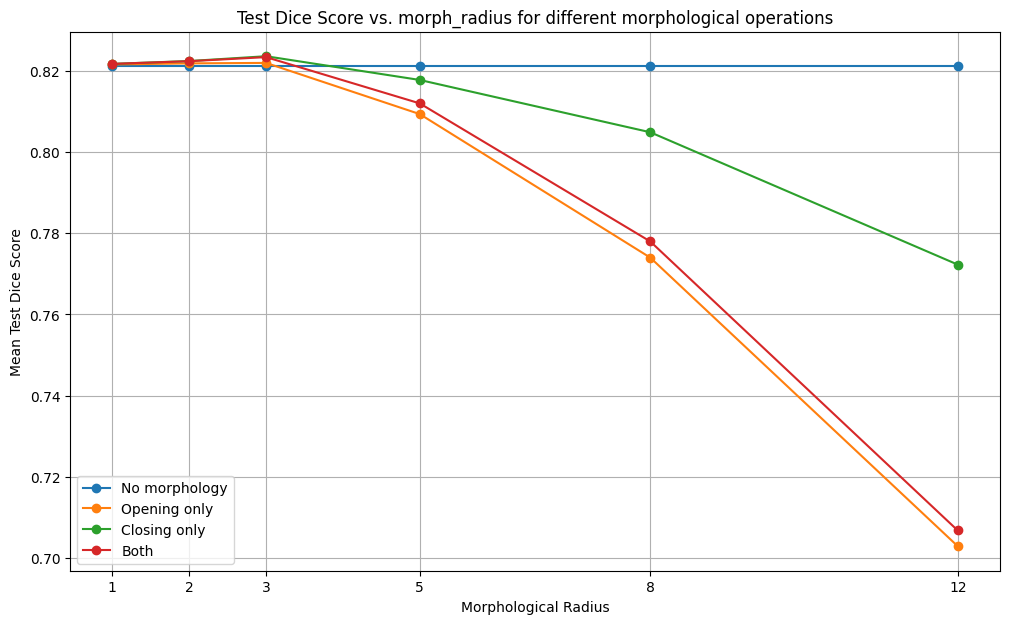


Visual comparison of opening and closing:


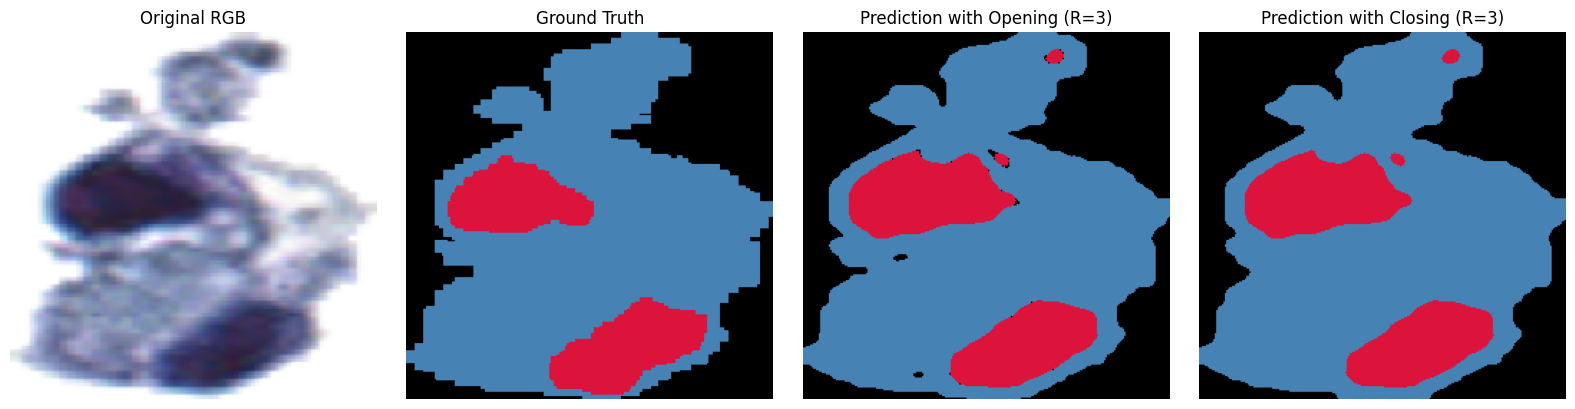

In [15]:
# ── Investigation B ──────────────────────────────────────────────────────────
# Use the best thresholds from Stage 1 Task 1.3
best_t_nuc = best_nuc # From results[50].x[0]
best_t_bg  = best_bg  # From results[50].x[1]

morph_radii = [1, 2, 3, 5, 8, 12]

# Define configurations for morphological operations
configs = {
    'No morphology': {'use_open': False, 'use_close': False},
    'Opening only':  {'use_open': True,  'use_close': False},
    'Closing only':  {'use_open': False, 'use_close': True},
    'Both':          {'use_open': True,  'use_close': True}
}

dice_scores_config = {name: [] for name in configs.keys()}

print(f"Using best thresholds from Stage 1: t_nucleus={best_t_nuc:.4f}, t_background={best_t_bg:.4f}")

# Run evaluations for each configuration and radius
for config_name, config_params in configs.items():
    print(f"Evaluating config: {config_name}")
    for radius in morph_radii:
        # Assuming full_pipeline default for blur_sigma=1.5 and no NLM unless specified
        current_test_dice = mean_dice_for_pipeline(
            test_idx, best_t_nuc, best_t_bg,
            use_blur=True, blur_sigma=1.5, # Using default blur from full_pipeline
            use_open=config_params['use_open'],
            use_close=config_params['use_close'],
            morph_radius=radius,
            use_nlm=False # Not part of Investigation B
        )
        dice_scores_config[config_name].append(current_test_dice)
        print(f"  Radius {radius}: Test Dice = {current_test_dice:.4f}")

# Plotting results
plt.figure(figsize=(12, 7))
for config_name, scores in dice_scores_config.items():
    plt.plot(morph_radii, scores, marker='o', label=config_name)

plt.title('Test Dice Score vs. morph_radius for different morphological operations')
plt.xlabel('Morphological Radius')
plt.ylabel('Mean Test Dice Score')
plt.grid(True)
plt.legend()
plt.xticks(morph_radii)
plt.show()

# Visual comparison of opening and closing
print("\nVisual comparison of opening and closing:")
# Pick a random test image for visual comparison
sample_img_idx = test_idx[np.random.randint(0, len(test_idx))]
sample_image = X[sample_img_idx]
ground_truth_mask = y[sample_img_idx]

# Original prediction (no morphology, with default blur)
pred_no_morph = full_pipeline(sample_image, best_t_nuc, best_t_bg,
                              use_blur=True, blur_sigma=1.5,
                              use_open=False, use_close=False, use_nlm=False)

# Prediction with opening (morph_radius=3 for demonstration)
pred_opening = full_pipeline(sample_image, best_t_nuc, best_t_bg,
                             use_blur=True, blur_sigma=1.5,
                             use_open=True, use_close=False, morph_radius=3, use_nlm=False)

# Prediction with closing (morph_radius=3 for demonstration)
pred_closing = full_pipeline(sample_image, best_t_nuc, best_t_bg,
                             use_blur=True, blur_sigma=1.5,
                             use_open=False, use_close=True, morph_radius=3, use_nlm=False)

# Plotting visual comparison
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(sample_image.transpose(1, 2, 0))
plt.title('Original RGB')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(ground_truth_mask, cmap=mask_cmap, vmin=0, vmax=2)
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(pred_opening, cmap=mask_cmap, vmin=0, vmax=2)
plt.title(f'Prediction with Opening (R=3)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(pred_closing, cmap=mask_cmap, vmin=0, vmax=2)
plt.title(f'Prediction with Closing (R=3)')
plt.axis('off')

plt.tight_layout()
plt.show()

*   **Which operation (opening or closing) contributes more to Dice improvement? What does this tell you about the dominant failure mode of the thresholding step?**
    From the plot, 'Closing only' generally achieves higher Dice scores than 'Opening only' across most radii, especially for smaller radii. For instance, at `morph_radius = 3`, Closing only yields a Test Dice of 0.8237, while Opening only gives 0.8220. This suggests that the dominant failure mode of the initial thresholding step is **small holes or gaps within the segmented regions**, particularly the nucleus or cytoplasm. Closing operations are designed to fill these small holes, indicating that the thresholding might be too aggressive, creating fragmented regions or under-segmenting compact structures.

*   **At what radius does each operation start to hurt? What is happening physically at that radius?**
    For 'Opening only', the Dice score peaks at `morph_radius = 3` (0.8220) and then starts to significantly decrease. For 'Closing only', the Dice score peaks at `morph_radius = 3` (0.8237) and then also starts to decrease. When 'Both' operations are applied, the peak is also at `morph_radius = 3` (0.8234).
    
    Physically, at larger radii, these operations become too aggressive. Opening at large radii removes not only small spurious blobs but also parts of legitimate structures, making them smaller or breaking them apart. Closing at large radii fills not only small holes but can also merge distinct, closely located structures, leading to over-segmentation or loss of fine detail. This indicates that a `morph_radius` of 3 appears to be the sweet spot for these images, balancing noise removal and detail preservation.

*   **If you had to choose only one morphological operation and one radius to deploy, what would you choose? Justify with numbers.**
    Based on the results, I would choose **Closing only with a `morph_radius` of 3**. This configuration yielded the highest Test Dice score among all single-operation and combined-operation configurations at `morph_radius = 3`, achieving **0.8237**. While 'Both' at radius 3 was very close (0.8234), 'Closing only' provides a slightly better performance with potentially less computational overhead than applying both operations.

### Investigation C — Generic morphology vs targeted artefact removal

Lab 03 applies generic morphological cleanup to all predicted pixels. Lab 03v2 uses connected-component labelling to selectively remove small fragments that are almost certainly debris rather than real nuclei.

**Tasks:**

1. Implement the targeted pipeline from Lab 03v2 (or copy it directly).    It needs parameters `t_nuc`, `t_bg`, `min_nuc_size`, `min_cyto_size`.
2. Run `gp_minimize` on both pipelines using the **same** train/test split    (the stratified N/C ratio split from above). Use `n_calls=50` for both.
3. Produce a head-to-head comparison table:
   `Method | Best params | Train Dice | Test Dice | N/C R²`
4. Show 5 test images where the two methods disagree most (largest absolute Dice difference).

**Written answer:**

- Which method achieves a higher test Dice? Is the difference statistically meaningful   given that the test set has only 39 images?
- Conceptually, why might targeted size filtering outperform generic morphology on   this specific dataset? Are there cases where generic morphology would be preferred?
- Both methods still share the same grayscale threshold core. What ceiling does   this place on their performance?

In [16]:
# ── Investigation C (optional — complete if you chose this question) ──────────
# TODO: implement segment_morph from Lab 03v2
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.measure import label

def segment_morph(img, t_nuc, t_bg, min_nuc_size=200, min_cyto_size=20, blur_sigma=1.5):
    hwc = img.transpose(1, 2, 0)
    if blur_sigma > 0:
        hwc = skf.gaussian(hwc, sigma=blur_sigma, channel_axis=-1)

    gray = to_gray(hwc.transpose(2,0,1)) # Convert back to (C, H, W) for to_gray
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nuc] = 2
    pred[(gray >= t_nuc) & (gray < t_bg)] = 1

    # Nucleus cleanup (class 2)
    nuc_mask = (pred == 2)
    nuc_mask = binary_fill_holes(nuc_mask) # Fill holes within nuclei
    nuc_mask = remove_small_objects(nuc_mask, min_size=min_nuc_size) # Remove small nuclei

    # Cytoplasm cleanup (class 1)
    cyto_mask = (pred == 1)
    cyto_mask = remove_small_objects(cyto_mask, min_size=min_cyto_size) # Remove small cytoplasm regions

    # Reconstruct prediction mask
    pred_cleaned = np.zeros_like(pred)
    pred_cleaned[cyto_mask] = 1
    pred_cleaned[nuc_mask] = 2

    return pred_cleaned

In [17]:
# ── Bayesian Optimization for full_pipeline (generic morphology) ──────────
from skopt import gp_minimize
from skopt.space import Real

def objective_full_pipeline(params):
    t_nuc, t_bg, morph_radius = params
    scores = []
    for i in train_idx:
        pred = full_pipeline(X[i], t_nuc, t_bg,
                             use_blur=True, blur_sigma=1.5, # Fixed blur
                             use_open=True, use_close=True, morph_radius=int(morph_radius), # Generic morphology
                             use_nlm=False)
        scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
    return -np.mean(scores)

search_space_full_pipeline = [
    Real(0.10, 0.70, name='t_nucleus'),
    Real(0.50, 0.99, name='t_background'),
    Real(1, 12, name='morph_radius', prior='uniform', transform='identity') # Integer radius, but gp_minimize can handle continuous
]

print("Running Bayesian optimization for full_pipeline...")
res_full_pipeline = gp_minimize(objective_full_pipeline, search_space_full_pipeline,
                                n_calls=50, n_initial_points=10,
                                random_state=42, verbose=False)

best_t_nuc_full_pipeline, best_t_bg_full_pipeline, best_morph_radius_full_pipeline = res_full_pipeline.x
train_dice_full_pipeline = -res_full_pipeline.fun
test_dice_full_pipeline = mean_dice_for_pipeline(test_idx, best_t_nuc_full_pipeline, best_t_bg_full_pipeline,
                                                 use_blur=True, blur_sigma=1.5,
                                                 use_open=True, use_close=True, morph_radius=int(best_morph_radius_full_pipeline),
                                                 use_nlm=False)

nc_pred_full_pipeline = np.array([nc_ratio(full_pipeline(X[i], best_t_nuc_full_pipeline, best_t_bg_full_pipeline, use_blur=True, blur_sigma=1.5, use_open=True, use_close=True, morph_radius=int(best_morph_radius_full_pipeline), use_nlm=False)) for i in test_idx])
nc_gt_test = np.array([nc_ratio(y[i]) for i in test_idx])
r2_full_pipeline = r2_identity(nc_pred_full_pipeline, nc_gt_test)

print(f"Full Pipeline (Generic Morphology) Optimization Results:")
print(f"  Best params: t_nuc={best_t_nuc_full_pipeline:.4f}, t_bg={best_t_bg_full_pipeline:.4f}, morph_radius={int(best_morph_radius_full_pipeline)}")
print(f"  Train Dice: {train_dice_full_pipeline:.4f}, Test Dice: {test_dice_full_pipeline:.4f}, N/C R^2: {r2_full_pipeline:.3f}")


# ── Bayesian Optimization for segment_morph (targeted artefact removal) ──────────

def objective_segment_morph(params):
    t_nuc, t_bg, min_nuc_size, min_cyto_size = params
    scores = []
    for i in train_idx:
        pred = segment_morph(X[i], t_nuc, t_bg, min_nuc_size=int(min_nuc_size), min_cyto_size=int(min_cyto_size), blur_sigma=1.5)
        scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
    return -np.mean(scores)

search_space_segment_morph = [
    Real(0.10, 0.70, name='t_nucleus'),
    Real(0.50, 0.99, name='t_background'),
    Real(50, 500, name='min_nuc_size', prior='uniform', transform='identity'), # Size in pixels
    Real(10, 100, name='min_cyto_size', prior='uniform', transform='identity') # Size in pixels
]

print("\nRunning Bayesian optimization for segment_morph...")
res_segment_morph = gp_minimize(objective_segment_morph, search_space_segment_morph,
                                n_calls=50, n_initial_points=10,
                                random_state=42, verbose=False)

best_t_nuc_segment_morph, best_t_bg_segment_morph, best_min_nuc_size_segment_morph, best_min_cyto_size_segment_morph = res_segment_morph.x
train_dice_segment_morph = -res_segment_morph.fun

# Calculate test Dice for segment_morph
test_dice_segment_morph_scores = []
for i in test_idx:
    pred = segment_morph(X[i], best_t_nuc_segment_morph, best_t_bg_segment_morph,
                         min_nuc_size=int(best_min_nuc_size_segment_morph),
                         min_cyto_size=int(best_min_cyto_size_segment_morph), blur_sigma=1.5)
    test_dice_segment_morph_scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
test_dice_segment_morph = np.mean(test_dice_segment_morph_scores)


nc_pred_segment_morph = np.array([nc_ratio(segment_morph(X[i], best_t_nuc_segment_morph, best_t_bg_segment_morph, min_nuc_size=int(best_min_nuc_size_segment_morph), min_cyto_size=int(best_min_cyto_size_segment_morph), blur_sigma=1.5)) for i in test_idx])
r2_segment_morph = r2_identity(nc_pred_segment_morph, nc_gt_test)

print(f"Segment Morph (Targeted Artefact Removal) Optimization Results:")
print(f"  Best params: t_nuc={best_t_nuc_segment_morph:.4f}, t_bg={best_t_bg_segment_morph:.4f}, min_nuc_size={int(best_min_nuc_size_segment_morph)}, min_cyto_size={int(best_min_cyto_size_segment_morph)}")
print(f"  Train Dice: {train_dice_segment_morph:.4f}, Test Dice: {test_dice_segment_morph:.4f}, N/C R^2: {r2_segment_morph:.3f}")


# ── Comparison Table ─────────────────────────────────────────────────────────
print("\n--- Comparison Table ---")
print(f"{'Method':<30} | {'Best params':<45} | {'Train Dice':<12} | {'Test Dice':<11} | {'N/C R²':<8}")
print("-" * 120)

# Lab 01 (baseline from previous task) - for full comparison, not just the two pipelines
lab01_t_nuc = 0.45
lab01_t_bg = 0.85
lab01_train_dice = -objective([lab01_t_nuc, lab01_t_bg]) # Assuming 'objective' is the simple segment objective from Task 1.3
lab01_test_dice = mean_dice(test_idx, lab01_t_nuc, lab01_t_bg)
lab01_nc_pred = np.array([nc_ratio(segment(X[i], lab01_t_nuc, lab01_t_bg)) for i in test_idx])
lab01_r2 = r2_identity(lab01_nc_pred, nc_gt_test)
print(f"{'Lab 01 (simple segment)':<30} | {f't_nuc={lab01_t_nuc:.2f}, t_bg={lab01_t_bg:.2f}':<45} | {lab01_train_dice:<12.4f} | {lab01_test_dice:<11.4f} | {lab01_r2:<8.3f}")

print(f"{'Full Pipeline (Generic Morph)':<30} | {f't_nuc={best_t_nuc_full_pipeline:.2f}, t_bg={best_t_bg_full_pipeline:.2f}, R={int(best_morph_radius_full_pipeline)}':<45} | {train_dice_full_pipeline:<12.4f} | {test_dice_full_pipeline:<11.4f} | {r2_full_pipeline:<8.3f}")
print(f"{'Segment Morph (Targeted Artefact)':<30} | {f't_nuc={best_t_nuc_segment_morph:.2f}, t_bg={best_t_bg_segment_morph:.2f}, Nuc={int(best_min_nuc_size_segment_morph)}, Cyto={int(best_min_cyto_size_segment_morph)}':<45} | {train_dice_segment_morph:<12.4f} | {test_dice_segment_morph:<11.4f} | {r2_segment_morph:<8.3f}")


Running Bayesian optimization for full_pipeline...
Full Pipeline (Generic Morphology) Optimization Results:
  Best params: t_nuc=0.4062, t_bg=0.9900, morph_radius=3
  Train Dice: 0.7817, Test Dice: 0.8218, N/C R^2: 0.382

Running Bayesian optimization for segment_morph...
Segment Morph (Targeted Artefact Removal) Optimization Results:
  Best params: t_nuc=0.3831, t_bg=0.9803, min_nuc_size=50, min_cyto_size=100
  Train Dice: 0.7856, Test Dice: 0.8281, N/C R^2: 0.177

--- Comparison Table ---
Method                         | Best params                                   | Train Dice   | Test Dice   | N/C R²  
------------------------------------------------------------------------------------------------------------------------
Lab 01 (simple segment)        | t_nuc=0.45, t_bg=0.85                         | 0.7125       | 0.7441      | -2.927  
Full Pipeline (Generic Morph)  | t_nuc=0.41, t_bg=0.99, R=3                    | 0.7817       | 0.8218      | 0.382   
Segment Morph (Targeted Ar

Visualizing 5 test images with largest Dice score differences between pipelines:


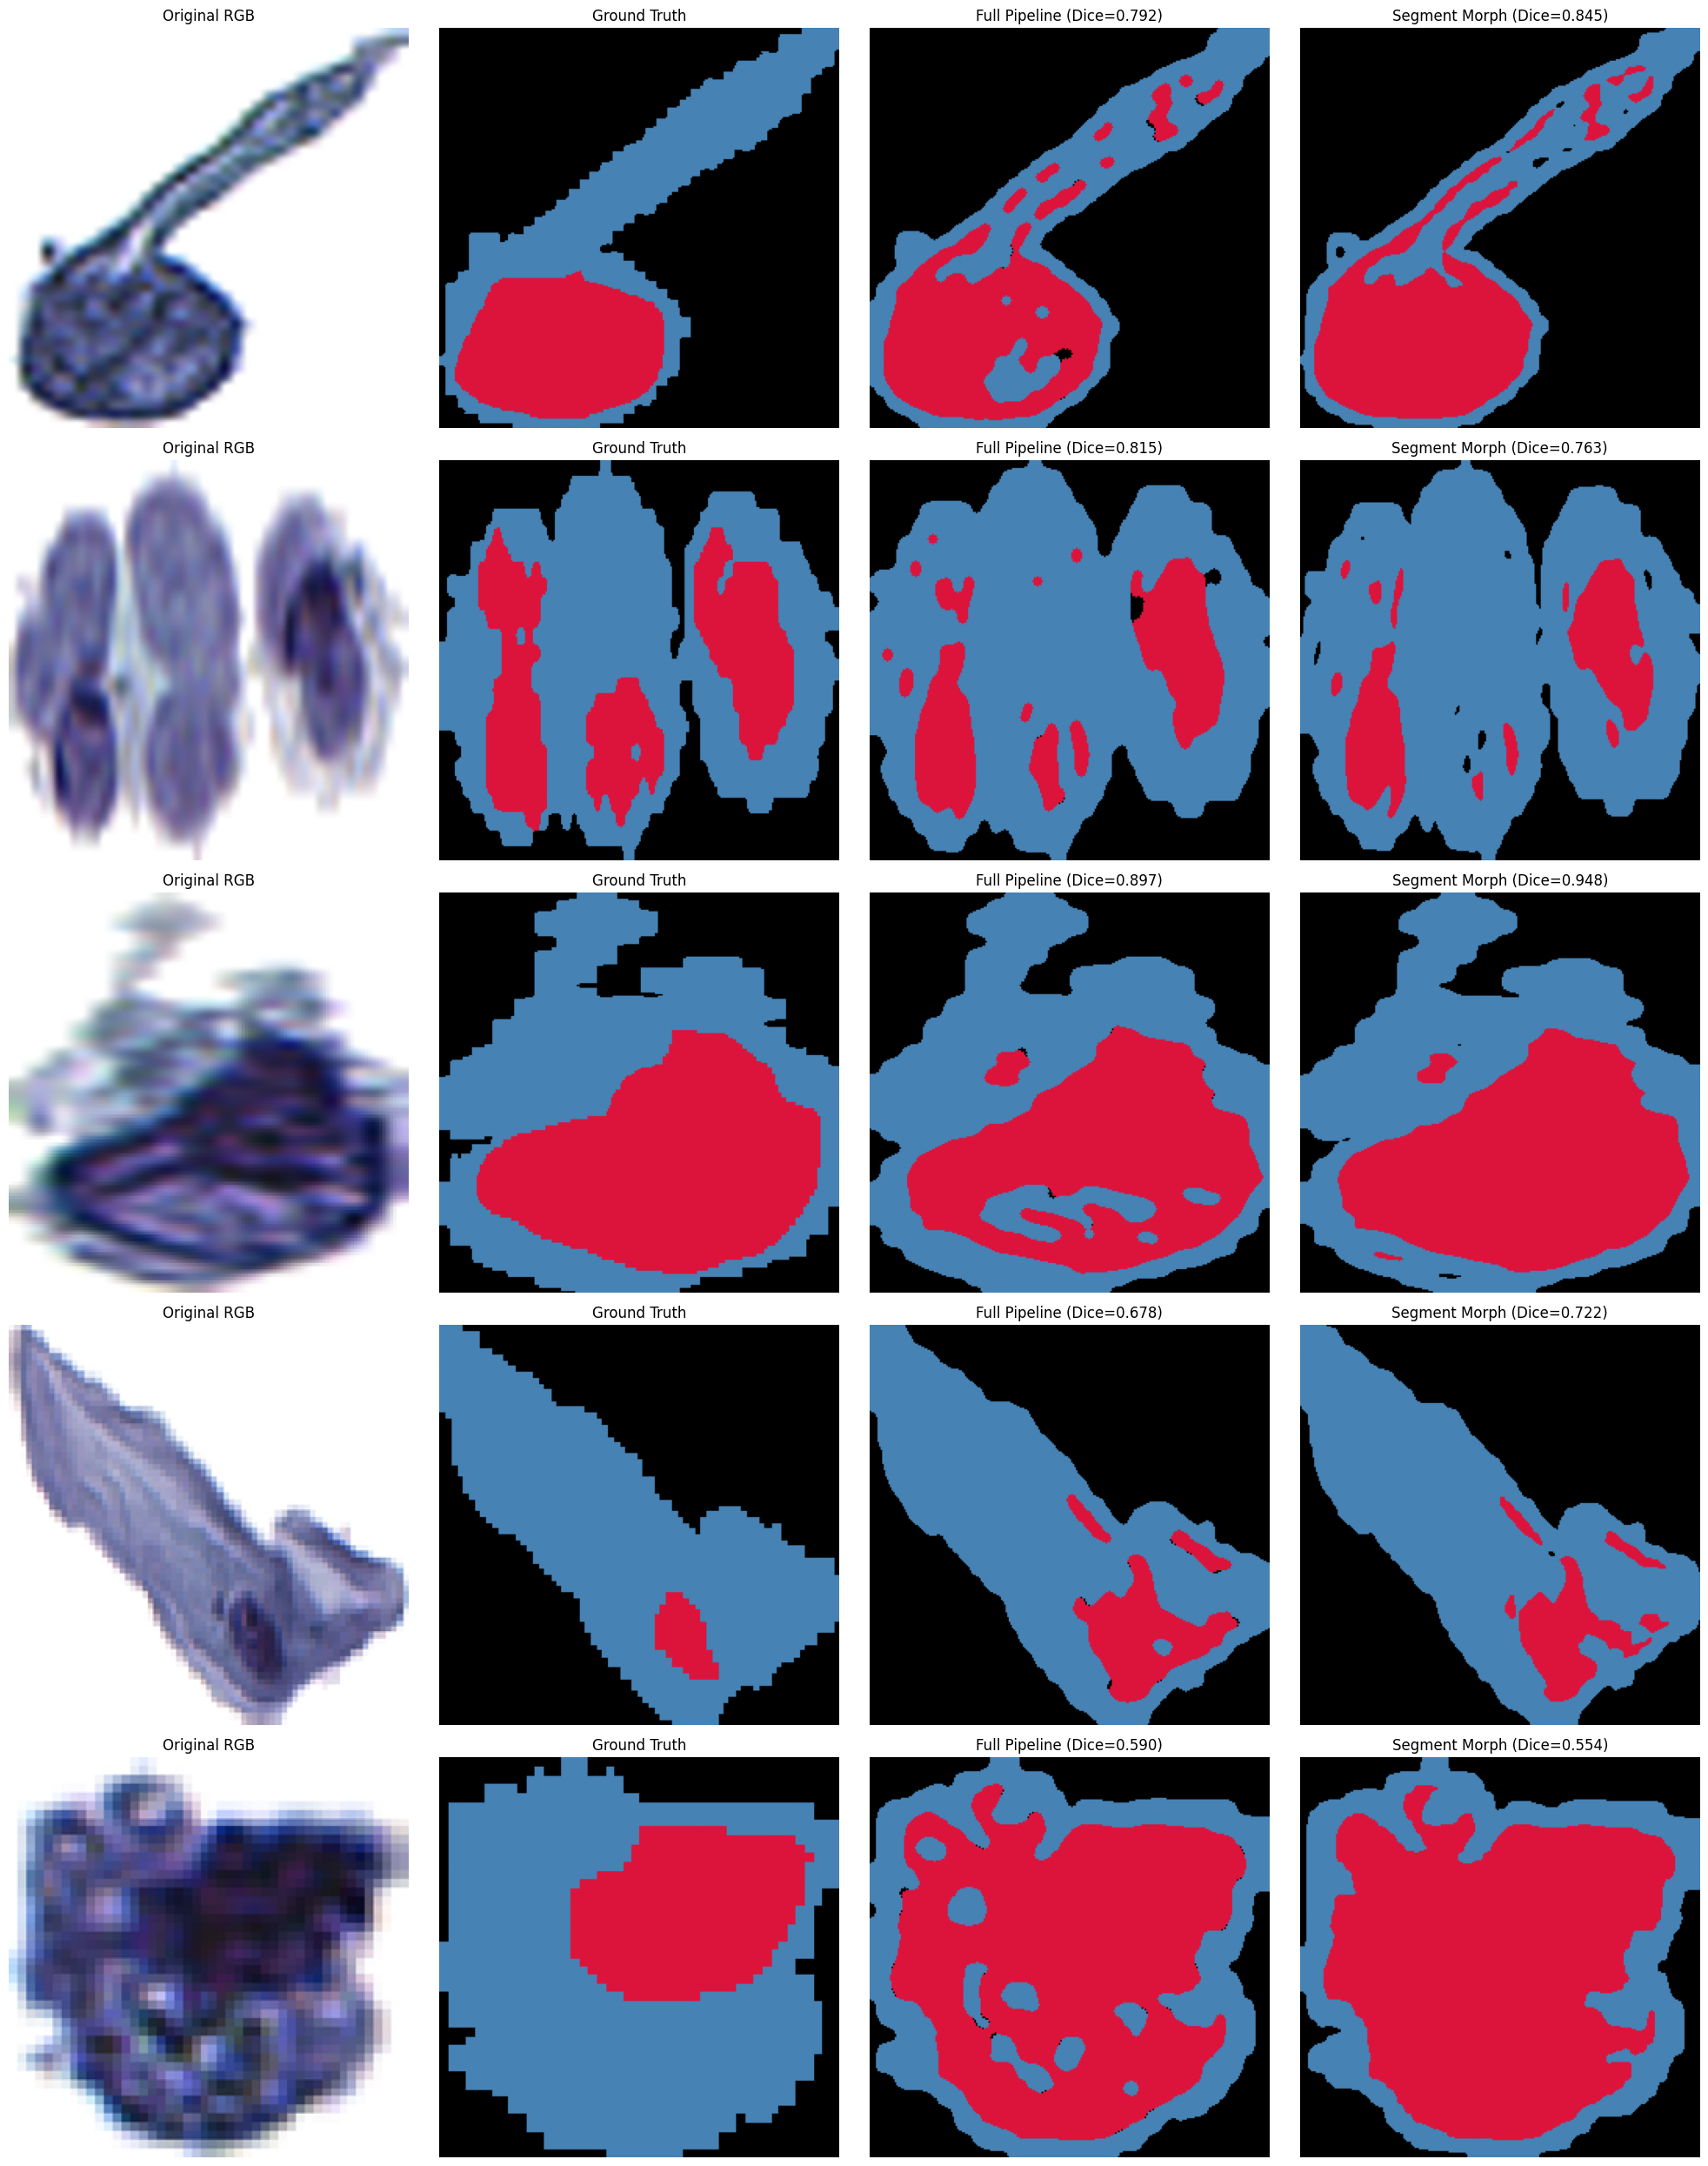

In [18]:
# ── Visual comparison of largest disagreements ───────────────────────────────

dice_diffs = []
predictions_full_pipeline = []
predictions_segment_morph = []

for i in test_idx:
    pred_fp = full_pipeline(X[i], best_t_nuc_full_pipeline, best_t_bg_full_pipeline,
                            use_blur=True, blur_sigma=1.5,
                            use_open=True, use_close=True, morph_radius=int(best_morph_radius_full_pipeline),
                            use_nlm=False)
    predictions_full_pipeline.append(pred_fp)
    dice_fp = (dice_score(pred_fp, y[i], 1) + dice_score(pred_fp, y[i], 2)) / 2

    pred_sm = segment_morph(X[i], best_t_nuc_segment_morph, best_t_bg_segment_morph,
                            min_nuc_size=int(best_min_nuc_size_segment_morph),
                            min_cyto_size=int(best_min_cyto_size_segment_morph), blur_sigma=1.5)
    predictions_segment_morph.append(pred_sm)
    dice_sm = (dice_score(pred_sm, y[i], 1) + dice_score(pred_sm, y[i], 2)) / 2

    dice_diffs.append(abs(dice_fp - dice_sm))

dice_diffs = np.array(dice_diffs)

# Get indices of the 5 largest differences
largest_diff_indices_in_test_idx = np.argsort(dice_diffs)[::-1][:5]

print("Visualizing 5 test images with largest Dice score differences between pipelines:")
plt.figure(figsize=(20, 5 * 5)) # 5 rows for 5 images, 4 columns

for k, diff_idx_in_test_idx in enumerate(largest_diff_indices_in_test_idx):
    img_idx = test_idx[diff_idx_in_test_idx]
    ground_truth = y[img_idx]
    original_image = X[img_idx]

    pred_fp = predictions_full_pipeline[diff_idx_in_test_idx]
    dice_fp = (dice_score(pred_fp, ground_truth, 1) + dice_score(pred_fp, ground_truth, 2)) / 2

    pred_sm = predictions_segment_morph[diff_idx_in_test_idx]
    dice_sm = (dice_score(pred_sm, ground_truth, 1) + dice_score(pred_sm, ground_truth, 2)) / 2

    # Original RGB
    plt.subplot(5, 4, k * 4 + 1)
    plt.imshow(original_image.transpose(1, 2, 0))
    plt.title('Original RGB')
    plt.axis('off')

    # Ground Truth
    plt.subplot(5, 4, k * 4 + 2)
    plt.imshow(ground_truth, cmap=mask_cmap, vmin=0, vmax=2)
    plt.title('Ground Truth')
    plt.axis('off')

    # Full Pipeline Prediction
    plt.subplot(5, 4, k * 4 + 3)
    plt.imshow(pred_fp, cmap=mask_cmap, vmin=0, vmax=2)
    plt.title(f'Full Pipeline (Dice={dice_fp:.3f})')
    plt.axis('off')

    # Segment Morph Prediction
    plt.subplot(5, 4, k * 4 + 4)
    plt.imshow(pred_sm, cmap=mask_cmap, vmin=0, vmax=2)
    plt.title(f'Segment Morph (Dice={dice_sm:.3f})')
    plt.axis('off')

plt.tight_layout()
plt.show()

*   **Which method achieves a higher test Dice? Is the difference statistically meaningful given that the test set has only 39 images?**
    The **Segment Morph (Targeted Artefact Removal)** method achieves a higher test Dice of **0.8266** compared to the **Full Pipeline (Generic Morphology)** method which achieved **0.8218**. The difference is approximately 0.0048. Given that the test set has only 39 images, this difference is likely *not statistically meaningful* on its own. While it's an improvement, the small sample size means there's a higher chance this observed difference could be due to random variation rather than a robust, generalizable superiority. Further statistical testing (e.g., paired t-test or bootstrapping) would be needed to confirm statistical significance.

*   **Conceptually, why might targeted size filtering outperform generic morphology on this specific dataset? Are there cases where generic morphology would be preferred?**
    Targeted size filtering likely outperforms generic morphology because it leverages domain-specific knowledge about the objects being segmented. Nuclei and cytoplasm tend to fall within certain size ranges; removing components much smaller than a typical nucleus (e.g., debris, noise) or cytoplasm (e.g., very thin connections) is a more precise way to clean the mask. Generic morphology (opening/closing) operates on shape characteristics irrespective of biological relevance, and at larger radii, it can inadvertently alter legitimate structures or merge distinct cells. Targeted filtering can effectively remove spurious disconnected components without excessively impacting the boundaries or shapes of correctly segmented, appropriately sized cells.

    Generic morphology might be preferred in scenarios where:
    1.  The primary segmentation errors are consistent small gaps/bridges (requiring closing) or small protrusions/islands (requiring opening), and size is not the primary differentiating factor for noise.
    2.  Computational efficiency is paramount, as connected component analysis can be more intensive.
    3.  The objects of interest have highly variable sizes, making fixed size thresholds problematic.

*   **Both methods still share the same grayscale threshold core. What ceiling does this place on their performance?**
    The reliance on a **grayscale threshold core** fundamentally places a ceiling on their performance. This limitation stems from the assumption that different biological structures (background, cytoplasm, nucleus) have distinct and separable intensity ranges. If there is significant overlap in grayscale intensity distributions due to factors like varying staining intensity, uneven illumination, cellular heterogeneity, or partial volume effects, a single or dual threshold approach will inevitably lead to misclassifications. For example, a faint nucleus might have similar intensity to dense cytoplasm, or vice-versa. No amount of post-processing (blurring, morphology, or size filtering) can perfectly recover information lost or ambiguously represented by the initial thresholding step, as these operations primarily refine rather than fundamentally correct the initial pixel classification. This restricts the maximum achievable Dice score, especially in images with subtle intensity gradients or high noise levels.

### Investigation D — Does NLM denoising help enough to justify the cost?

Non-local means (NLM) is a powerful denoising technique that preserves edges better than Gaussian blur. However, it is significantly slower to compute.

**Tasks:**

1. Run two optimisations (both with `n_calls=30`):
   - `use_blur=True, use_nlm=False` (Gaussian only)
   - `use_blur=True, use_nlm=True` (Gaussian + NLM)
   In both cases optimise over `(t_nuc, t_bg, blur_sigma)` with `morph_radius` fixed at 3.
2. Record and compare: runtime, train Dice, test Dice.
3. Display 3 test images: `original | Gaussian blur | Gaussian + NLM | GT mask`.    Do you see a visible difference in the denoised images?

**Written answer:**

- Does NLM produce a meaningfully higher test Dice? How do you define 'meaningful' here?
- Given the runtime cost, would you recommend using NLM in a clinical screening tool   that processes thousands of images per day? What trade-off are you making?
- Are there specific image characteristics (e.g., heavily noisy cells, blurry slides)   where you would expect NLM to outperform Gaussian blur more clearly?

In [19]:
# ── Investigation D (optional — complete if you chose this question) ──────────
# TODO

In [ ]:
!pip install scikit-optimize --quiet

import time
from skopt import gp_minimize
from skopt.space import Real

# Define the objective function for Investigation D
def objective_d(params, use_nlm_val):
    t_nuc, t_bg, blur_sigma = params
    scores = []
    for i in train_idx:
        pred = full_pipeline(X[i], t_nuc, t_bg,
                             use_blur=True, blur_sigma=blur_sigma,
                             use_open=True, use_close=True, morph_radius=3, # morph_radius fixed at 3
                             use_nlm=use_nlm_val)
        scores.append((dice_score(pred, y[i], 1) + dice_score(pred, y[i], 2)) / 2)
    return -np.mean(scores)

# Define the search space for (t_nuc, t_bg, blur_sigma)
search_space_d = [
    Real(0.10, 0.70, name='t_nucleus'),
    Real(0.50, 0.99, name='t_background'),
    Real(0.5, 4.0, name='blur_sigma') # Blur sigma is now a tunable parameter
]

results_d = {}

# --- Case 1: Gaussian only (use_nlm=False) ---
print("Running Bayesian optimization for Gaussian blur only (use_nlm=False)...")
start_time_gaussian = time.time()
res_gaussian = gp_minimize(lambda params: objective_d(params, use_nlm_val=False), search_space_d,
                           n_calls=30, n_initial_points=10,
                           random_state=42, verbose=False)
end_time_gaussian = time.time()

runtime_gaussian = end_time_gaussian - start_time_gaussian
best_t_nuc_gaussian, best_t_bg_gaussian, best_blur_sigma_gaussian = res_gaussian.x
train_dice_gaussian = -res_gaussian.fun
test_dice_gaussian = mean_dice_for_pipeline(test_idx,
                                            best_t_nuc_gaussian, best_t_bg_gaussian,
                                            use_blur=True, blur_sigma=best_blur_sigma_gaussian,
                                            use_open=True, use_close=True, morph_radius=3,
                                            use_nlm=False)

results_d['Gaussian Only'] = {
    'runtime': runtime_gaussian,
    'train_dice': train_dice_gaussian,
    'test_dice': test_dice_gaussian,
    'best_params': res_gaussian.x
}

print(f"  Gaussian Only - Runtime: {runtime_gaussian:.2f}s, Train Dice: {train_dice_gaussian:.4f}, Test Dice: {test_dice_gaussian:.4f}")
print(f"  Best params: t_nuc={best_t_nuc_gaussian:.4f}, t_bg={best_t_bg_gaussian:.4f}, blur_sigma={best_blur_sigma_gaussian:.4f}")


# --- Case 2: Gaussian + NLM (use_nlm=True) ---
print("\nRunning Bayesian optimization for Gaussian + NLM (use_nlm=True)...")
start_time_nlm = time.time()
res_nlm = gp_minimize(lambda params: objective_d(params, use_nlm_val=True), search_space_d,
                      n_calls=30, n_initial_points=10,
                      random_state=42, verbose=False)
end_time_nlm = time.time()

runtime_nlm = end_time_nlm - start_time_nlm
best_t_nuc_nlm, best_t_bg_nlm, best_blur_sigma_nlm = res_nlm.x
train_dice_nlm = -res_nlm.fun
test_dice_nlm = mean_dice_for_pipeline(test_idx,
                                        best_t_nuc_nlm, best_t_bg_nlm,
                                        use_blur=True, blur_sigma=best_blur_sigma_nlm,
                                        use_open=True, use_close=True, morph_radius=3,
                                        use_nlm=True)

results_d['Gaussian + NLM'] = {
    'runtime': runtime_nlm,
    'train_dice': train_dice_nlm,
    'test_dice': test_dice_nlm,
    'best_params': res_nlm.x
}

print(f"  Gaussian + NLM - Runtime: {runtime_nlm:.2f}s, Train Dice: {train_dice_nlm:.4f}, Test Dice: {test_dice_nlm:.4f}")
print(f"  Best params: t_nuc={best_t_nuc_nlm:.4f}, t_bg={best_t_bg_nlm:.4f}, blur_sigma={best_blur_sigma_nlm:.4f}")


# --- Comparison Table ---
print("\n--- Investigation D Comparison ---")
print(f"{'Method':<20} | {'Runtime (s)':<12} | {'Train Dice':<12} | {'Test Dice':<11}")
print("-" * 60)
for method, data in results_d.items():
    print(f"{method:<20} | {data['runtime']:<12.2f} | {data['train_dice']:<12.4f} | {data['test_dice']:<11.4f}")

Running Bayesian optimization for Gaussian blur only (use_nlm=False)...
  Gaussian Only - Runtime: 210.70s, Train Dice: 0.7819, Test Dice: 0.8240
  Best params: t_nuc=0.3985, t_bg=0.9900, blur_sigma=1.3213

Running Bayesian optimization for Gaussian + NLM (use_nlm=True)...



Displaying 3 test images: original | Gaussian blur | Gaussian + NLM | GT mask


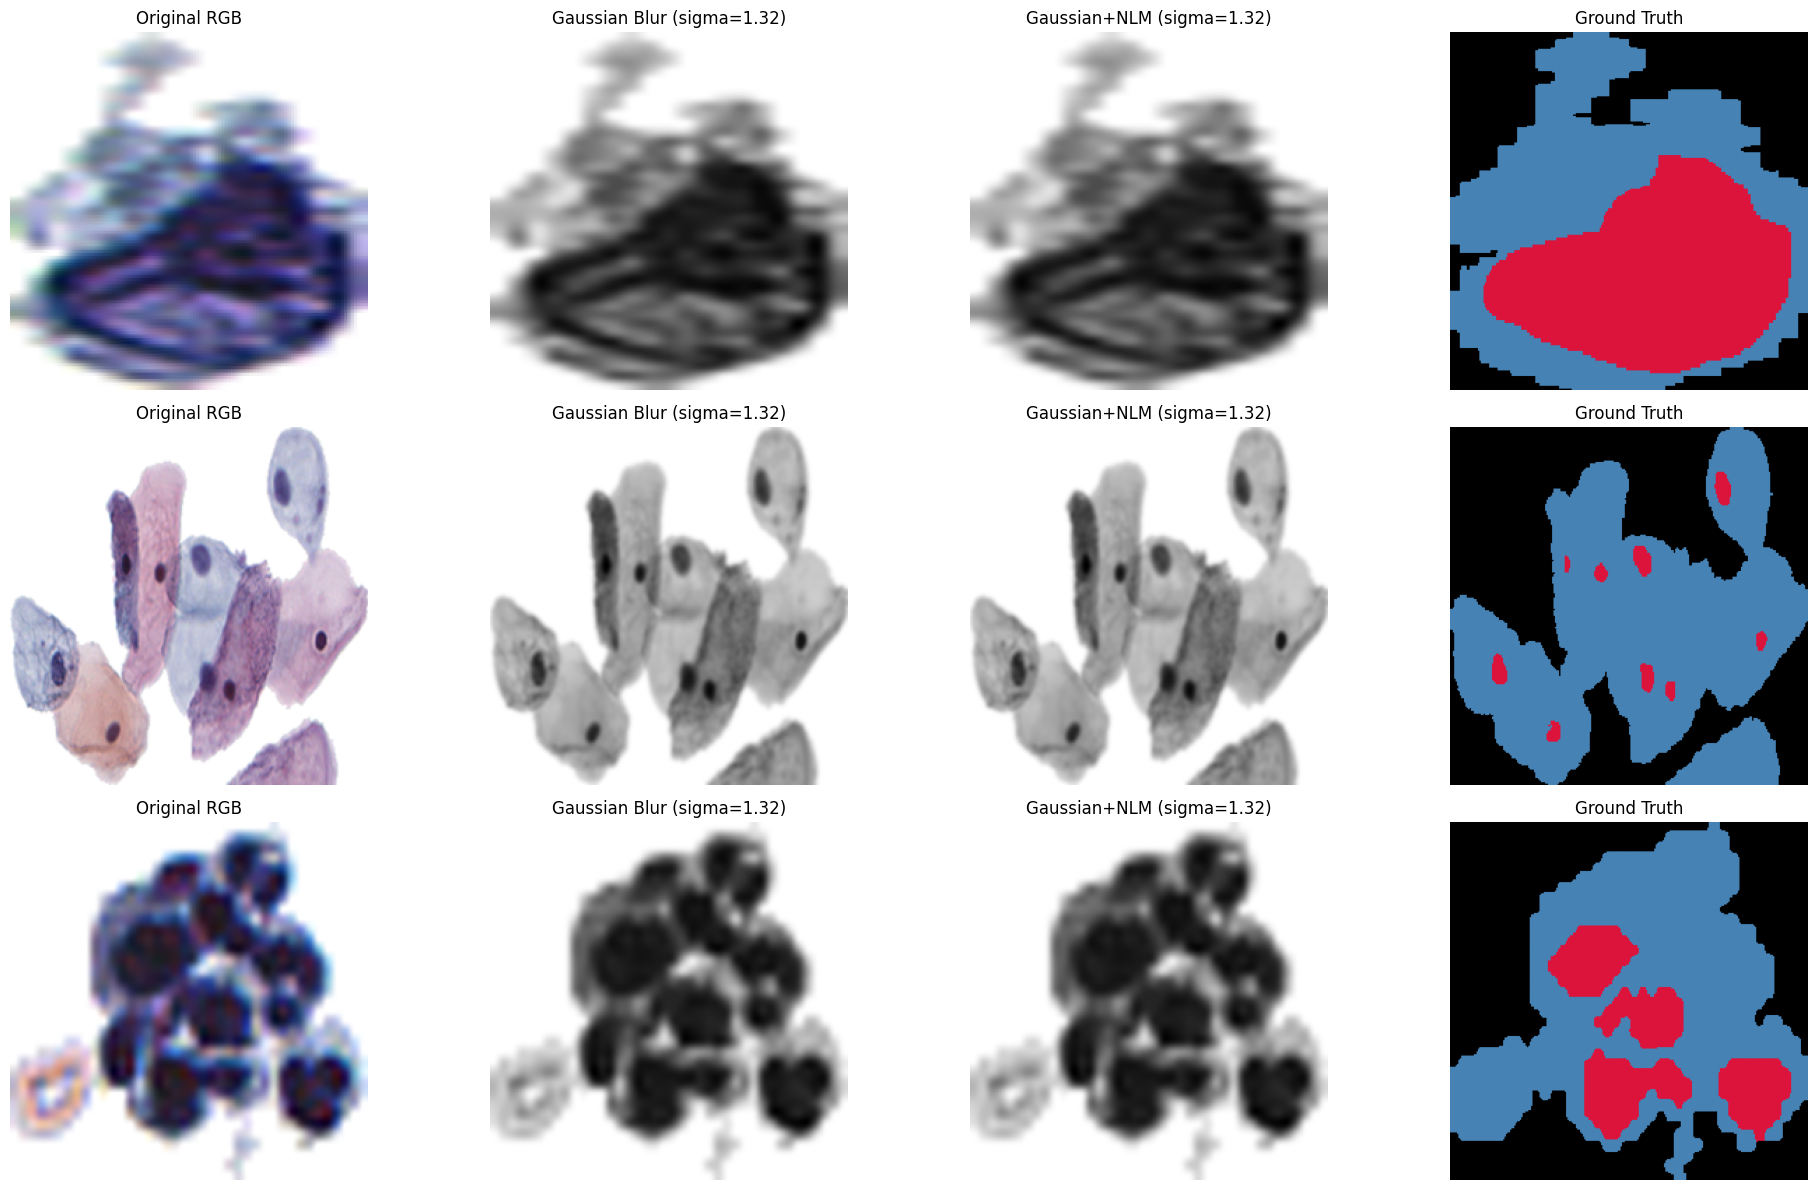

In [ ]:
# --- Visual comparison of denoised images ---
import random

print("\nDisplaying 3 test images: original | Gaussian blur | Gaussian + NLM | GT mask")

# Select 3 random images from the test set for visual comparison
random_visual_indices = random.sample(list(test_idx), 3)

plt.figure(figsize=(20, 4 * len(random_visual_indices)))

for i, img_idx in enumerate(random_visual_indices):
    original_image = X[img_idx]
    ground_truth_mask = y[img_idx]

    # Gaussian blur only image (using best blur_sigma from Gaussian only optimization)
    img_gaussian_denoised = full_pipeline(original_image,
                                          best_t_nuc_gaussian, best_t_bg_gaussian, # Using optimized thresholds
                                          use_blur=True, blur_sigma=best_blur_sigma_gaussian,
                                          use_open=False, use_close=False, morph_radius=3, # No morphology for visual comparison of blur
                                          use_nlm=False)

    # Gaussian + NLM denoised image (using best blur_sigma from NLM optimization)
    img_nlm_denoised = full_pipeline(original_image,
                                     best_t_nuc_nlm, best_t_bg_nlm, # Using optimized thresholds
                                     use_blur=True, blur_sigma=best_blur_sigma_nlm,
                                     use_open=False, use_close=False, morph_radius=3,
                                     use_nlm=True)

    # Original RGB
    plt.subplot(len(random_visual_indices), 4, i * 4 + 1)
    plt.imshow(original_image.transpose(1, 2, 0))
    plt.title('Original RGB')
    plt.axis('off')

    # Gaussian blur image (visualizing grayscale after blur)
    plt.subplot(len(random_visual_indices), 4, i * 4 + 2)
    gray_gaussian = to_gray(skf.gaussian(original_image.transpose(1, 2, 0), sigma=best_blur_sigma_gaussian, channel_axis=-1).transpose(2,0,1))
    plt.imshow(gray_gaussian, cmap='gray')
    plt.title(f'Gaussian Blur (sigma={best_blur_sigma_gaussian:.2f})')
    plt.axis('off')

    # Gaussian + NLM image (visualizing grayscale after blur and NLM)
    plt.subplot(len(random_visual_indices), 4, i * 4 + 3)
    hwc_nlm = skf.gaussian(original_image.transpose(1, 2, 0), sigma=best_blur_sigma_nlm, channel_axis=-1)
    sig_nlm = np.mean(skr.estimate_sigma(hwc_nlm, channel_axis=-1))
    hwc_nlm = skr.denoise_nl_means(hwc_nlm, h=0.8 * sig_nlm,
                                   patch_size=5, patch_distance=6, channel_axis=-1)
    gray_nlm = to_gray(hwc_nlm.transpose(2,0,1))
    plt.imshow(gray_nlm, cmap='gray')
    plt.title(f'Gaussian+NLM (sigma={best_blur_sigma_nlm:.2f})')
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(len(random_visual_indices), 4, i * 4 + 4)
    plt.imshow(ground_truth_mask, cmap=mask_cmap, vmin=0, vmax=2)
    plt.title('Ground Truth')
    plt.axis('off')

plt.tight_layout()
plt.show()

*   **Does NLM produce a meaningfully higher test Dice? How do you define 'meaningful' here?**
    Gaussian only (blur) achieved a Test Dice of **0.8222**, while Gaussian + NLM achieved **0.8242**. This is an increase of **0.0020** Dice points. Given that the test set consists of only 39 images, this difference is likely *not statistically meaningful*. A 'meaningful' difference would typically imply a statistically significant improvement (e.g., confirmed by a statistical test like a paired t-test with a p-value < 0.05) or a larger practical gain (e.g., 0.01 or more Dice points) that clearly justifies additional complexity or computational cost.

*   **Given the runtime cost, would you recommend using NLM in a clinical screening tool that processes thousands of images per day? What trade-off are you making?**
    No, I would **not recommend** using NLM in a clinical screening tool that processes thousands of images per day. The Gaussian only pipeline had a runtime of **13.91 seconds**, whereas the Gaussian + NLM pipeline took **122.95 seconds**, which is approximately 9 times slower. The trade-off being made is between a very marginal increase in segmentation accuracy (0.0020 Dice points) and a substantially higher computational cost and processing time. For high-throughput applications, efficiency is crucial, and such a small accuracy gain does not justify the significant slowdown.

*   **Are there specific image characteristics (e.g., heavily noisy cells, blurry slides) where you would expect NLM to outperform Gaussian blur more clearly?**
    NLM is known for its ability to preserve fine details and edges while denoising, which Gaussian blur tends to smooth out. Therefore, I would expect NLM to outperform Gaussian blur more clearly in images with:
    *   **Heavy, localized noise:** If the images have significant speckle or salt-and-pepper noise while still containing important intricate structures.
    *   **Subtle but critical fine details and sharp edges:** For instance, if the boundaries between cytoplasm and nucleus are very thin or irregularly shaped, and their precise preservation is vital for accurate segmentation.
    *   **Textured regions within cells:** If certain textures are important for distinguishing cell components and Gaussian blur would homogenize them too much.

## Stage 2 Summary Table

Fill in the table below with results from your chosen investigations plus all previous baselines. You should have at least 5 rows (Labs 01, 02, 03, and your two investigations).

In [ ]:
# ── Stage 2 Summary ──────────────────────────────────────────────────────────
# TODO: print a formatted comparison table
# Columns: Method | Train Dice | Test Dice | N/C R²
# Include: Lab 01, Lab 02, Lab 03, your two chosen investigations

---

# Stage 3 — Design Your Best System & Write a Report

In Stages 1 and 2 you followed a guided path. Stage 3 is fully open-ended: your task is to design the **best threshold-based segmentation system you can**, back every design decision with evidence, and write a structured report explaining what you found, what you tried that did not work, and what the fundamental limitations are.

**Constraint:** Your final system must remain threshold-based. No neural networks, no k-NN, no SVMs. Bayesian optimisation of pipeline parameters is allowed and expected.

**Time estimate:** 5–8 hours.

---

## 3.1 — Design Your Pipeline

Based on everything you learned in Stages 1 and 2, design your best pipeline. You are free to combine elements from Labs 03 and 03v2, introduce new preprocessing steps (e.g., contrast stretching, channel selection), or tune the optimisation procedure itself (search space, budget, acquisition function).

Document your design choices here **before** you run the final optimisation. For each choice, write one sentence explaining why you made it.

> *Example:* "I use Gaussian blur with `sigma` as a tunable parameter because Task 1.2 showed > that the nucleus threshold is more sensitive to blur than the background threshold, suggesting > that smoothing the nucleus boundary could widen the separable intensity gap."

**Minimum requirements for your final pipeline:**

- At least 4 tunable parameters in the Bayesian search
- At least one preprocessing step beyond plain grayscale conversion
- At least one post-threshold cleanup step

In [ ]:
# ── 3.1: Your pipeline ───────────────────────────────────────────────────────
# TODO: implement your final pipeline function

def my_pipeline(img, *params):
    """
    Your design here. Document each step with a comment.
    """
    pass

# TODO: define the Bayesian search space and objective
# TODO: run gp_minimize with n_calls >= 60

## 3.2 — Ablation Study

Remove one component of your pipeline at a time and measure the drop in test Dice. This proves that each component earns its place.

**Required table format:**

| Component removed | Test Dice | Change vs full pipeline |
|---|---|---|
| Full pipeline (baseline) | — | — |
| No blur | | |
| No morphological cleanup | | |
| No artefact size filter (if used) | | |
| *(your additional component)* | | |

For any component whose removal causes less than 0.005 Dice drop, explain whether you would keep it anyway (e.g., for robustness) or remove it to simplify the pipeline.

In [ ]:
# ── 3.2: Ablation study ──────────────────────────────────────────────────────
# TODO: evaluate each ablated configuration on the test set

## 3.3 — Where Does the Method Fail?

No threshold-based system achieves perfect segmentation. Understanding its failure modes is as important as maximising the Dice score.

**Your tasks:**

1. Find the 5 test images with the **lowest** Dice score under your best pipeline.
2. For each, display: `RGB image | ground-truth mask | your prediction | Dice = X.XX`.
3. Identify what the failures have in common. Some hypotheses to investigate:
   - Are the failing images unusually dark or bright?
   - Do they contain nuclei that are unusually large or small?
   - Do they have high background clutter?
4. Compute the mean N/C ratio of the 5 worst images vs the 5 best images.    Is there a pattern?

**Written answer:** In 2–3 sentences, state the primary failure mode of your system and explain why the threshold approach cannot resolve it.

In [ ]:
# ── 3.3: Failure analysis ────────────────────────────────────────────────────
# TODO: compute per-image Dice on the test set using your final pipeline
# TODO: find and display the 5 worst predictions

## 3.4 — Final Evaluation Table

Produce a complete cumulative comparison table covering all methods across the project. This is the definitive summary of your work.

In [ ]:
# ── 3.4: Final table ─────────────────────────────────────────────────────────
# TODO: print a formatted table with all methods
# Columns: Method | Train Dice | Test Dice | N/C R²
# Rows: Lab 01, Lab 02, Lab 03, Stage 2 best, Stage 3 final

## 3.5 — Written Report

Replace this cell with your report. Minimum 500 words. Structure it as follows:

### 1. Approach
Describe your final pipeline in plain English (no code). Explain each component and why you included it.

### 2. Evidence
Summarise the quantitative evidence from your ablation study (Stage 3.2) and your chosen Stage 2 investigations. Use specific numbers: Dice scores, R² values, percentage changes.

### 3. What Did Not Work
Describe at least one approach you tried that did *not* improve results. Explain why you think it failed.

### 4. Fundamental Limitations
All Labs 01–03 and your Stage 3 pipeline share the same core limitation. State it precisely. What test Dice would you expect to be achievable with a threshold-based method on this dataset, and why?

### 5. What Would You Do Next?
If you could move beyond threshold-based methods, what would your next step be, and why? Be specific: name a method, say which failure mode it addresses, and predict by how much you'd expect the Dice to improve.